# 04 Visualizations

This notebook creates plots for the final report and poster.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

In [2]:
cosine_shift = pd.read_csv(RESULTS_DIR / "cosine_shift.csv")
group_shift = pd.read_csv(RESULTS_DIR / "group_shift.csv")
neighbors = pd.read_csv(RESULTS_DIR / "nearest_neighbors.csv")

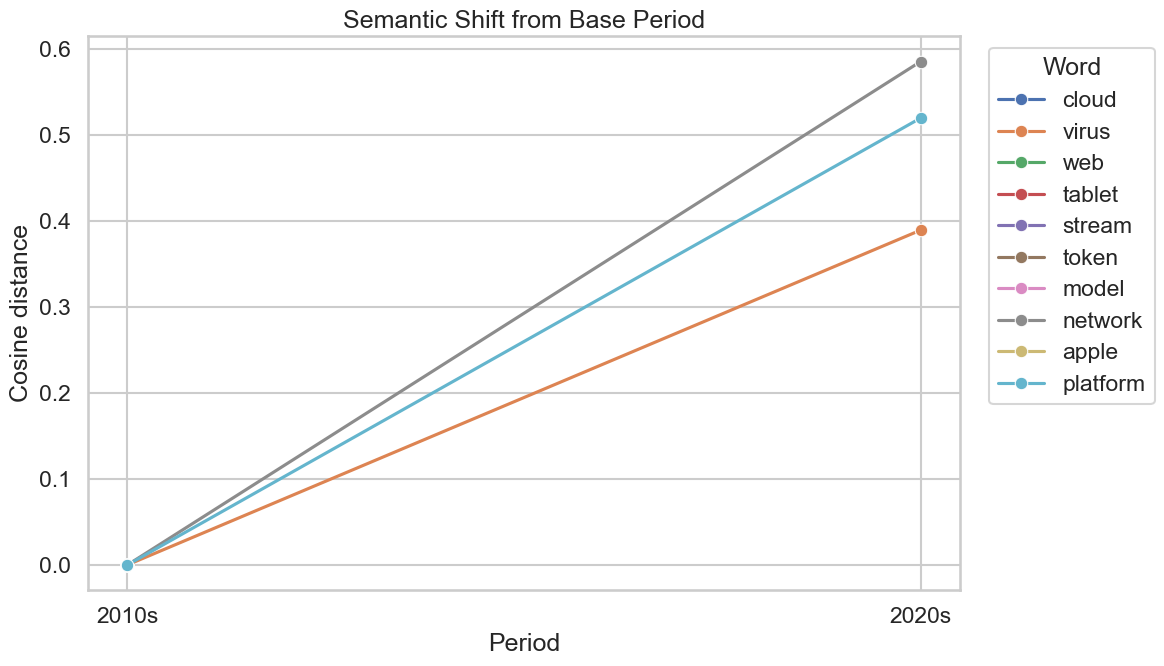

In [3]:
target_words = ["cloud", "virus", "web", "tablet", "stream", "token", "model", "network", "apple", "platform"]
plot_df = cosine_shift[cosine_shift["word"].isin(target_words)]

plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df, x="period", y="cosine_distance", hue="word", marker="o")
plt.title("Semantic Shift from Base Period")
plt.xlabel("Period")
plt.ylabel("Cosine distance")
plt.legend(title="Word", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shift_scores.png", dpi=200)
plt.show()

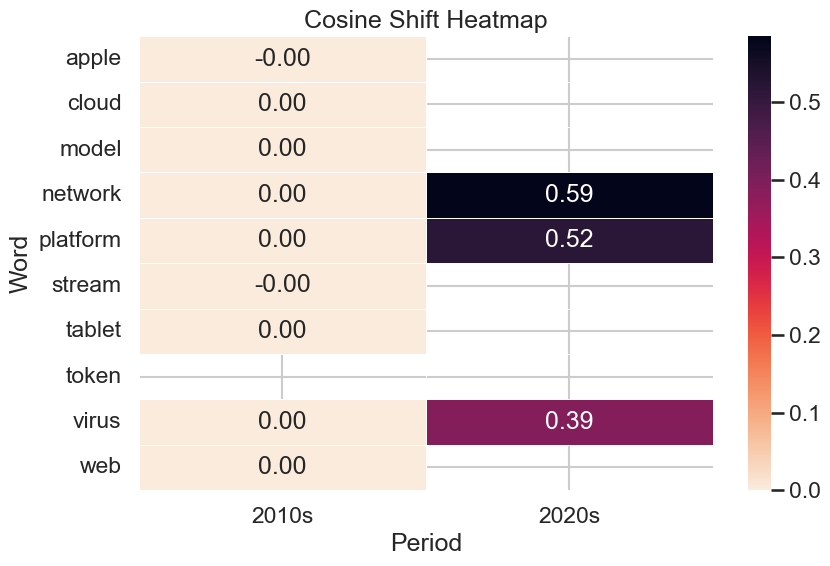

In [4]:
heatmap_df = plot_df.pivot(index="word", columns="period", values="cosine_distance")

plt.figure(figsize=(9, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="rocket_r", linewidths=0.5)
plt.title("Cosine Shift Heatmap")
plt.xlabel("Period")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shift_heatmap.png", dpi=200)
plt.show()

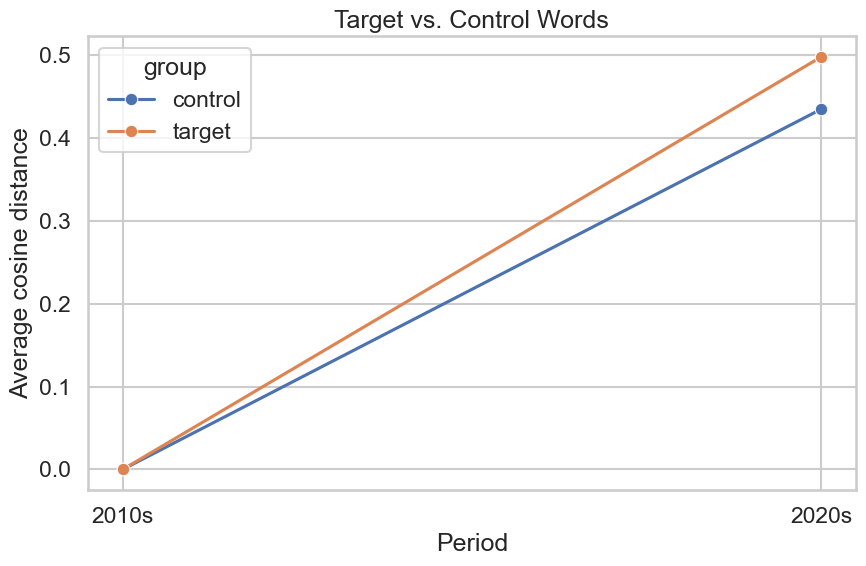

In [5]:
plt.figure(figsize=(9, 6))
sns.lineplot(data=group_shift, x="period", y="cosine_distance", hue="group", marker="o")
plt.title("Target vs. Control Words")
plt.xlabel("Period")
plt.ylabel("Average cosine distance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_vs_control.png", dpi=200)
plt.show()

In [6]:
neighbors_table = neighbors.pivot(index="word", columns="period", values="neighbors")
neighbors_table.loc[[word for word in ["cloud", "token", "virus", "stream"] if word in neighbors_table.index]]

period,2010s,2020s
word,,
cloud,"robotic, volcanic, abyss, computing, quantum, ...",NaN
token,NaN,NaN
virus,"zika, infections, transmission, outbreaks, vac...","disease, cdc, cases, china, deaths, outbreak, ..."
stream,"streaming, streams, flurry, networks, itunes, ...",NaN
